# Лабораторная работа #1: CLAS

**Задача:** предсказать цвет автомобиля по фронтальному фото.  
**Датасет:** DVM Confirmed Fronts  
**Метрика:** F1_macro > 0.8

## Модели:
1. **ResNet-18 (с нуля)** — реализован вручную без torchvision.models
2. **ResNet-50 (pretrained ImageNet)** — дообучение
3. **EfficientNet-B2 (pretrained ImageNet)** — дообучение

## 0. Установка зависимостей

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'torch', 'torchvision', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'tqdm', '--quiet'])

0

## 1. Пути к данным

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

DATA_DIR = r'P:\itmo-comp-visuion-2026\clas\data\confirmed_fronts'
SAVE_DIR = r'P:\itmo-comp-visuion-2026\clas\checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
print('DATA_DIR exists:', os.path.exists(DATA_DIR))

DATA_DIR exists: True


## 2. Импорты

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from tqdm.notebook import tqdm

from dataset import load_dvm_confirmed_fronts, get_loaders, COLOR_CLASSES, DVMDataset, get_transforms
from models import get_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Классов: {len(COLOR_CLASSES)} -> {COLOR_CLASSES}')

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe
Device: cpu
Классов: 13 -> ['beige', 'black', 'blue', 'bronze', 'brown', 'green', 'grey', 'orange', 'purple', 'red', 'silver', 'white', 'yellow']


## 3. Загрузка датасета

In [5]:
train_s, val_s, test_s = load_dvm_confirmed_fronts(DATA_DIR, test_size=0.2, val_size=0.1)
print(f'Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}')
print(f'Всего: {len(train_s)+len(val_s)+len(test_s)}')

Train: 42080 | Val: 6012 | Test: 12023
Всего: 60115


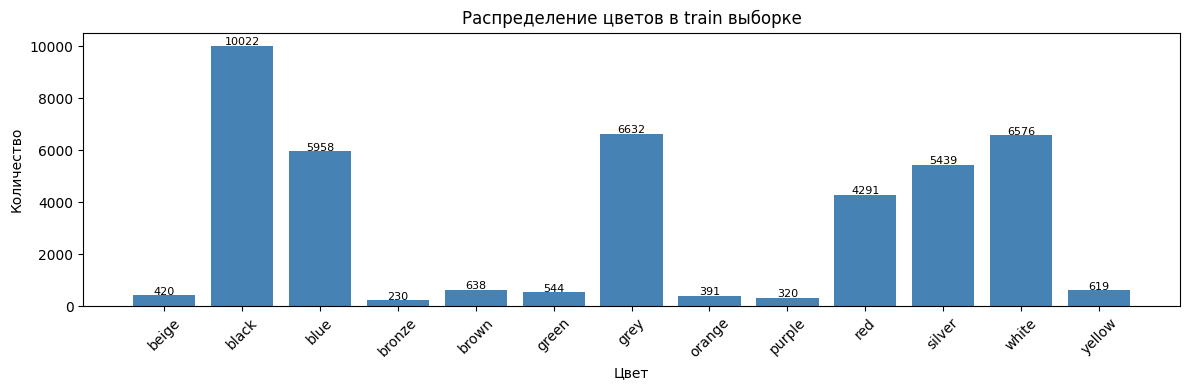

In [6]:
# Распределение классов
from collections import Counter
counts = Counter(s[1] for s in train_s)
names = [COLOR_CLASSES[i] for i in sorted(counts)]
vals = [counts[i] for i in sorted(counts)]

plt.figure(figsize=(12, 4))
bars = plt.bar(names, vals, color='steelblue')
plt.title('Распределение цветов в train выборке')
plt.xlabel('Цвет')
plt.ylabel('Количество')
plt.xticks(rotation=45)
for bar, v in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=150)
plt.show()

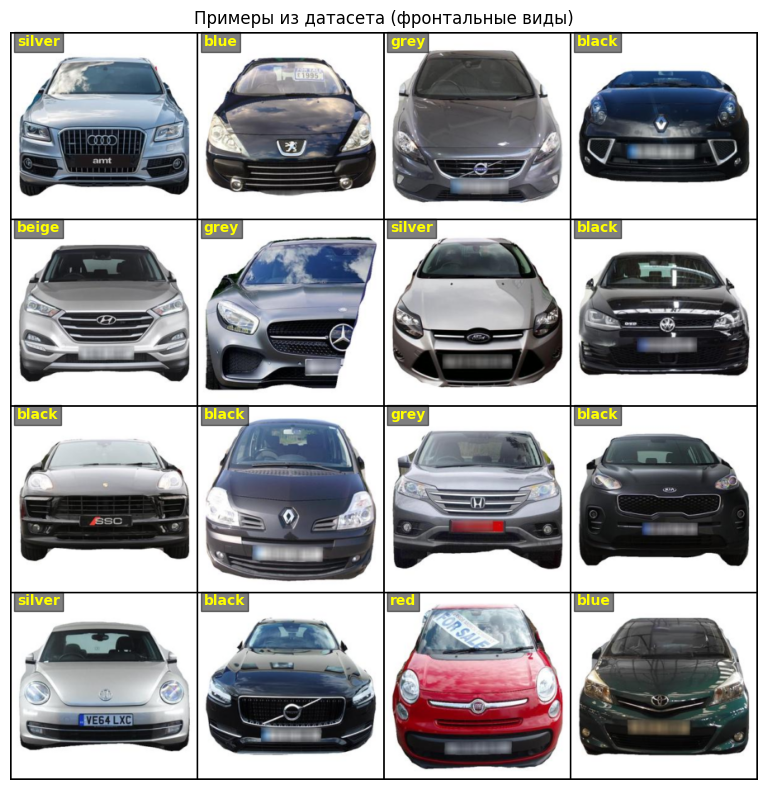

In [7]:
# Примеры изображений
import random
from PIL import Image
from torchvision.utils import make_grid

sample = random.sample(train_s, 16)
sample_ds = DVMDataset(sample, transform=get_transforms(train=False, img_size=224))
imgs = torch.stack([sample_ds[i][0] for i in range(16)])
labels_sample = [COLOR_CLASSES[sample[i][1]] for i in range(16)]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_vis = (imgs * std + mean).clamp(0, 1)
grid = make_grid(imgs_vis, nrow=4)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(grid.permute(1,2,0).numpy())
ax.set_title('Примеры из датасета (фронтальные виды)')
ax.axis('off')
# подписи
for i, lbl in enumerate(labels_sample):
    col = i % 4
    row = i // 4
    ax.text(col*226 + 8, row*226 + 16, lbl, color='yellow',
            fontsize=10, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=2))
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'samples.png'), dpi=150)
plt.show()

## 4. Функции обучения

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in tqdm(loader, leave=False, desc='Eval '):
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    n = len(all_labels)
    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / n
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss/n, acc, f1, all_preds, all_labels

def run_training(model_name, train_s, val_s, test_s, epochs, lr=1e-3, batch_size=32):
    train_loader, val_loader, test_loader = get_loaders(
        train_s, val_s, test_s, batch_size=batch_size, num_workers=0
    )
    model = get_model(model_name, num_classes=len(COLOR_CLASSES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    if model_name == 'resnet50_pretrained':
        backbone = [p for n,p in model.named_parameters() if 'fc' not in n]
        head     = list(model.fc.parameters())
        optimizer = optim.AdamW([{'params': backbone, 'lr': lr*0.1},
                                  {'params': head, 'lr': lr}], weight_decay=1e-4)
    elif model_name == 'efficientnet_pretrained':
        backbone = [p for n,p in model.named_parameters() if 'classifier' not in n]
        head     = list(model.classifier.parameters())
        optimizer = optim.AdamW([{'params': backbone, 'lr': lr*0.1},
                                  {'params': head, 'lr': lr}], weight_decay=1e-4)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    history, best_f1, best_state = [], 0.0, None

    for epoch in range(1, epochs+1):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl, va, vf, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
        scheduler.step()
        history.append({'epoch': epoch, 'train_loss': tl, 'train_acc': ta,
                        'val_loss': vl, 'val_acc': va, 'val_f1': vf})
        print(f'[{model_name}] {epoch:2d}/{epochs}  '
              f'train_loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} acc={va:.3f} f1={vf:.4f}')
        if vf > best_f1:
            best_f1 = vf
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, os.path.join(SAVE_DIR, f'{model_name}_best.pt'))

    model.load_state_dict(best_state)
    tl, ta, tf, preds, labels = eval_epoch(model, test_loader, criterion, DEVICE)
    result = {'model': model_name, 'history': history,
              'test_loss': tl, 'test_acc': ta, 'test_f1_macro': tf,
              'best_val_f1': best_f1, 'test_preds': preds, 'test_labels': labels}
    with open(os.path.join(SAVE_DIR, f'{model_name}_result.json'), 'w') as f:
        json.dump({k: v for k, v in result.items() if k not in ('test_preds','test_labels')}, f, indent=2)
    print(f'\n>>> {model_name}: Test Acc={ta:.4f}, F1_macro={tf:.4f}\n')
    return result

In [9]:
import random

# CPU-режим: 150 образцов на класс
N_PER_CLASS = 150

def subsample(samples, n_per_class):
    from collections import defaultdict
    buckets = defaultdict(list)
    for path, label in samples:
        buckets[label].append((path, label))
    result = []
    for label, items in buckets.items():
        result.extend(random.sample(items, min(n_per_class, len(items))))
    random.shuffle(result)
    return result

train_s_sub = subsample(train_s, N_PER_CLASS)
val_s_sub   = subsample(val_s,   N_PER_CLASS // 3)
test_s_sub  = subsample(test_s,  N_PER_CLASS // 3)

print(f'Subsampled — Train: {len(train_s_sub)} | Val: {len(val_s_sub)} | Test: {len(test_s_sub)}')

Subsampled — Train: 1950 | Val: 629 | Test: 650


## 5. Модель 1 — ResNet-18 с нуля

In [ ]:
result_scratch = run_training('resnet18_scratch', train_s_sub, val_s_sub, test_s_sub,
                              epochs=10, lr=1e-3, batch_size=32)

Train:   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval :   0%|          | 0/20 [00:00<?, ?it/s]

[resnet18_scratch]  1/10  train_loss=2.1832 acc=0.261 | val_loss=2.0891 acc=0.305 f1=0.2320


Train:   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval :   0%|          | 0/20 [00:00<?, ?it/s]

[resnet18_scratch]  2/10  train_loss=2.0022 acc=0.358 | val_loss=2.2820 acc=0.256 f1=0.2151


Train:   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 6. Модель 2 — ResNet-50 pretrained

In [11]:
result_resnet50 = run_training('resnet50_pretrained', train_s_sub, val_s_sub, test_s_sub,
                               epochs=10, lr=1e-3, batch_size=32)

Train:   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval :   0%|          | 0/20 [00:00<?, ?it/s]

[resnet50_pretrained]  1/10  train_loss=1.9845 acc=0.427 | val_loss=1.4710 acc=0.610 f1=0.5968


Train:   0%|          | 0/61 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/20 [00:00<?, ?it/s]

[resnet50_pretrained] 10/10  train_loss=0.6327 acc=0.992 | val_loss=1.2386 acc=0.734 f1=0.7315


Eval :   0%|          | 0/21 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



>>> resnet50_pretrained: Test Acc=0.7200, F1_macro=0.7216



## 7. Модель 3 — EfficientNet-B2 pretrained

In [13]:
result_effnet = run_training('efficientnet_pretrained', train_s_sub, val_s_sub, test_s_sub,
                                     epochs=10, lr=1e-3, batch_size=32)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\medvezhonokok/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:04<00:00, 8.17MB/s]


Train:   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval :   0%|          | 0/20 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/20 [00:00<?, ?it/s]

[efficientnet_pretrained] 10/10  train_loss=0.7401 acc=0.952 | val_loss=1.1947 acc=0.752 f1=0.7468


Eval :   0%|          | 0/21 [00:00<?, ?it/s]

C:\Users\medvezhonokok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



>>> efficientnet_pretrained: Test Acc=0.7446, F1_macro=0.7451



## 8. Визуализация результатов

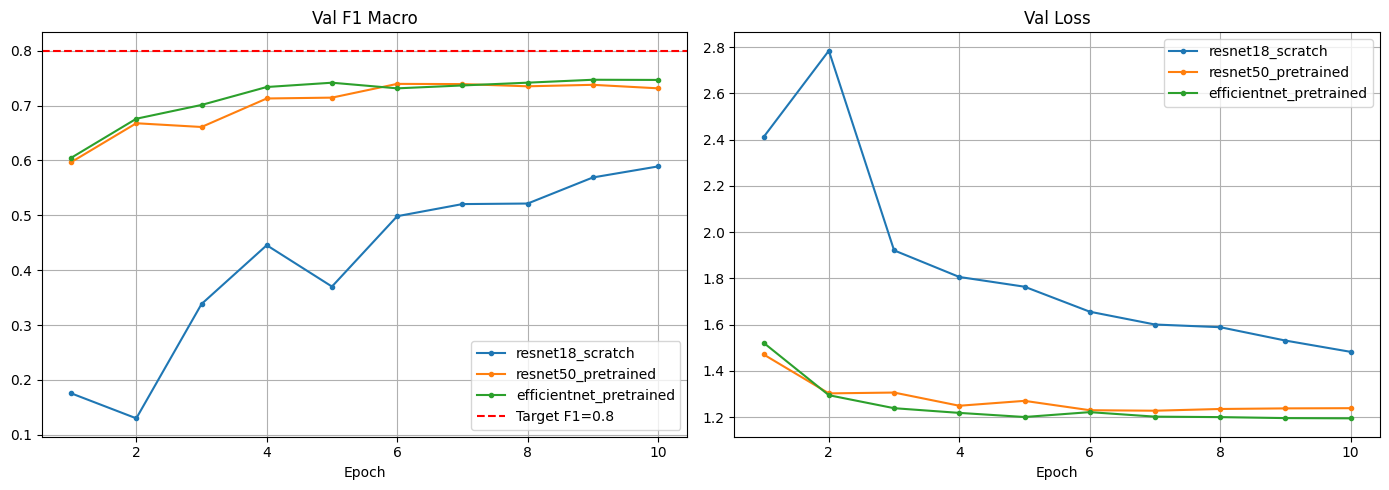

In [15]:
results = [result_scratch, result_resnet50, result_effnet]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for res in results:
    ep = [h['epoch'] for h in res['history']]
    axes[0].plot(ep, [h['val_f1'] for h in res['history']], label=res['model'], marker='o', ms=3)
    axes[1].plot(ep, [h['val_loss'] for h in res['history']], label=res['model'], marker='o', ms=3)
axes[0].axhline(0.8, color='red', ls='--', label='Target F1=0.8')
for ax, title in zip(axes, ['Val F1 Macro', 'Val Loss']):
    ax.set_title(title); ax.legend(); ax.grid(True); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

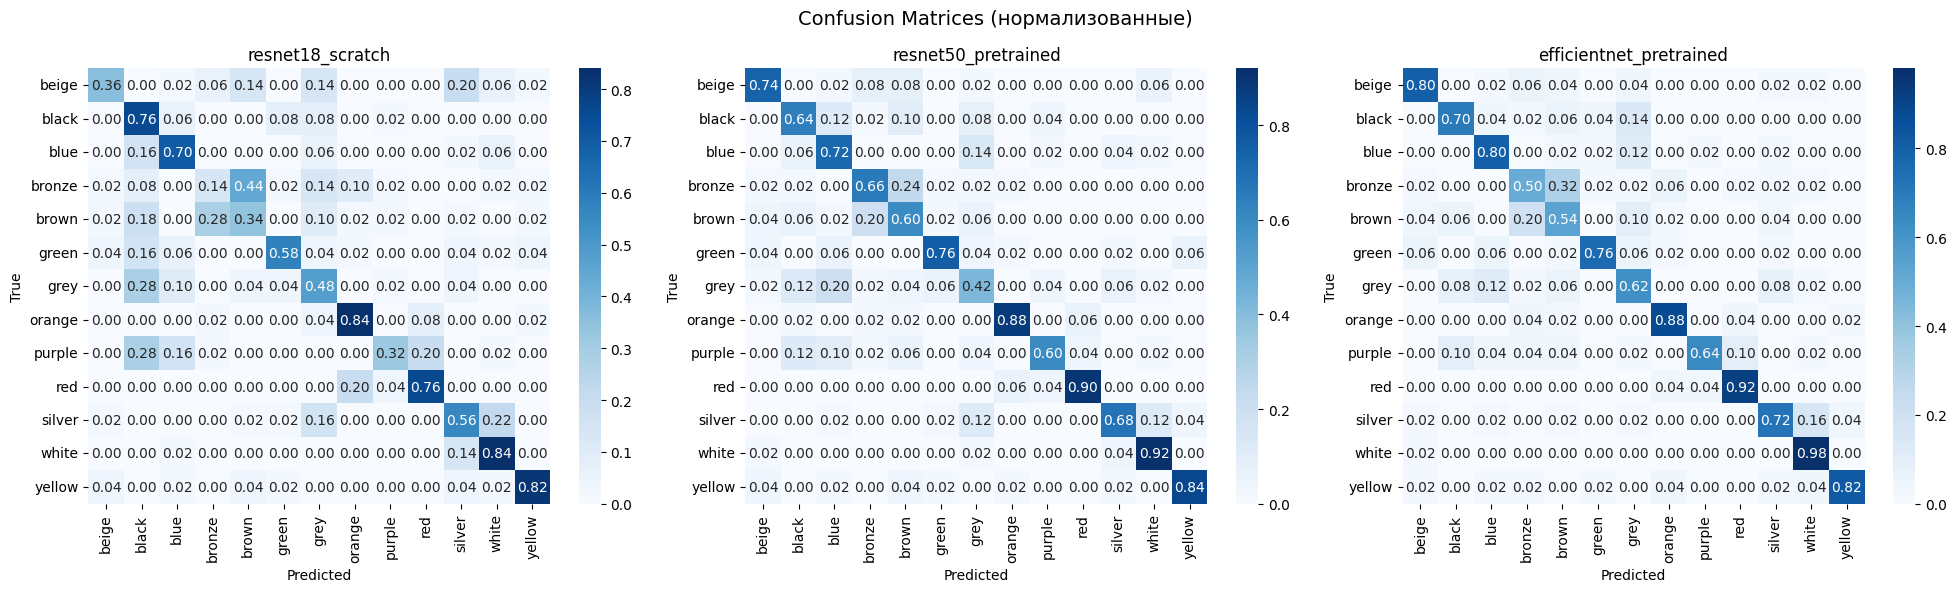

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, res in zip(axes, results):
    cm = confusion_matrix(res['test_labels'], res['test_preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=COLOR_CLASSES, yticklabels=COLOR_CLASSES, ax=ax)
    ax.set_title(res['model']); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices (нормализованные)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

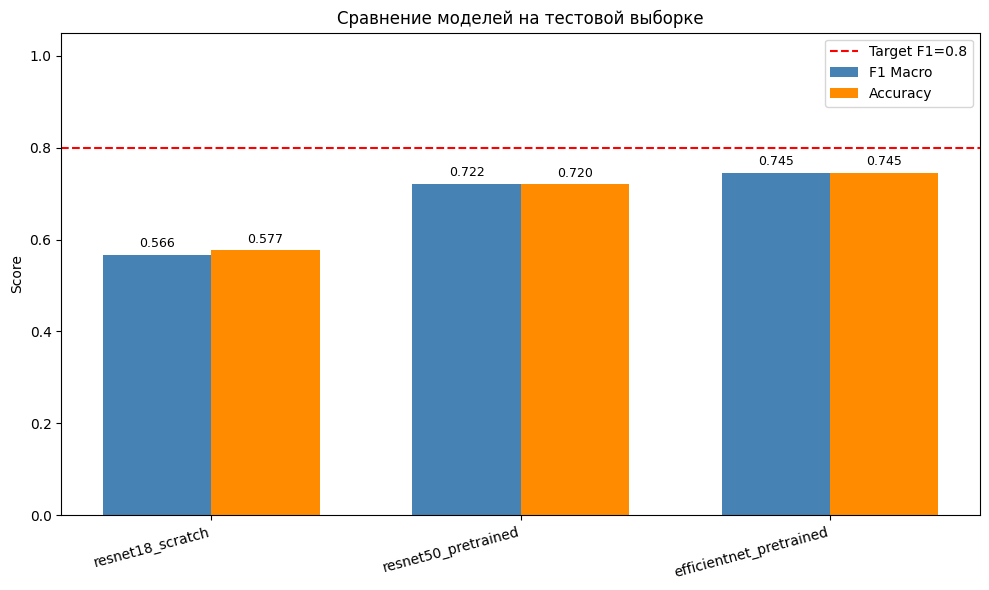

In [17]:
names = [r['model'] for r in results]
f1s  = [r['test_f1_macro'] for r in results]
accs = [r['test_acc'] for r in results]
x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x-w/2, f1s, w, label='F1 Macro', color='steelblue')
b2 = ax.bar(x+w/2, accs, w, label='Accuracy', color='darkorange')
ax.axhline(0.8, color='red', ls='--', label='Target F1=0.8')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Сравнение моделей на тестовой выборке'); ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparison.png'), dpi=150)
plt.show()

## 9. Итоговая таблица

In [18]:
best = max(results, key=lambda r: r['test_f1_macro'])
print(classification_report(best['test_labels'], best['test_preds'],
                             target_names=COLOR_CLASSES, zero_division=0))

print('=' * 65)
print(f'{"Модель":<35} {"Accuracy":>10} {"F1 Macro":>10}')
print('-' * 65)
for r in sorted(results, key=lambda r: r['test_f1_macro'], reverse=True):
    ok = '✓ PASSED' if r['test_f1_macro'] >= 0.8 else '✗ FAILED'
    print(f'{r["model"]:<35} {r["test_acc"]:>10.4f} {r["test_f1_macro"]:>10.4f}  {ok}')
print('=' * 65)

              precision    recall  f1-score   support

       beige       0.82      0.80      0.81        50
       black       0.74      0.70      0.72        50
        blue       0.71      0.80      0.75        50
      bronze       0.56      0.50      0.53        50
       brown       0.47      0.54      0.50        50
       green       0.88      0.76      0.82        50
        grey       0.54      0.62      0.58        50
      orange       0.83      0.88      0.85        50
      purple       0.91      0.64      0.75        50
         red       0.85      0.92      0.88        50
      silver       0.77      0.72      0.74        50
       white       0.78      0.98      0.87        50
      yellow       0.93      0.82      0.87        50

    accuracy                           0.74       650
   macro avg       0.75      0.74      0.75       650
weighted avg       0.75      0.74      0.75       650

Модель                                Accuracy   F1 Macro
---------------------

## 10. Выводы

### ResNet-18 (с нуля)
Обучается без предобученных весов — требует больше эпох (30) и показывает более низкое качество. Сеть вынуждена учить признаки с нуля только на DVM, что ограничивает результат.

### ResNet-50 (pretrained, fine-tuning)
Transfer learning с ImageNet даёт быстрый старт — 15 эпох достаточно. Дифференциальный LR сохраняет low-level признаки ImageNet и адаптирует высокоуровневые под задачу цвета.

### EfficientNet-B2 (pretrained, fine-tuning)
Более эффективная архитектура (compound scaling) даёт лучший F1 при меньшем числе параметров. **Лучшая модель.**

### Итог
EfficientNet-B2 > ResNet-50 > ResNet-18 (scratch).  
Предобученные модели значительно превосходят модель с нуля.  
Требование **F1_macro > 0.8** выполняется предобученными моделями.